# ☕ 咖啡进口数据可视化

本 Notebook 基于坚果云的 China_Import 数据创建可视化图表。

**数据源**: Supply_Demand BS.xlsx - China_Import Sheet

**主要可视化内容**:
1. 按国家分类的单月进口数量分析
2. 累计进口数量趋势
3. 主要进口来源国对比

---

## 📋 步骤 1: 导入库和配置环境

In [4]:
# 导入必要的库
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 添加项目路径
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置绘图风格
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("✅ 库导入完成！")
print(f"📁 项目根目录: {project_root}")

✅ 库导入完成！
📁 项目根目录: /Users/caddyzhang/Documents/X_Codes/Caddy's data


## 📥 步骤 2: 从坚果云加载数据

使用之前配置好的坚果云连接加载 China_Import 数据。

In [5]:
# 导入坚果云加载器
from src.visualization.nutstore_loader import NutStoreLoader

# 配置凭证（从 .streamlit/secrets.toml 读取或直接填入）
NUTSTORE_EMAIL = "caddy.zhang@starstream.com.cn"
NUTSTORE_APP_PASSWORD = "antwjfc7gjfa9qqp"

# 创建加载器
print("🔌 正在连接坚果云...")
loader = NutStoreLoader(
    email=NUTSTORE_EMAIL,
    app_password=NUTSTORE_APP_PASSWORD
)

if loader.check_connection():
    print("✅ 连接成功！")
else:
    print("❌ 连接失败，请检查凭证")

INFO:src.visualization.nutstore_loader:✅ 成功连接到坚果云


🔌 正在连接坚果云...
✅ 连接成功！


In [6]:
# 加载 Excel 数据
REMOTE_PATH = "Gondwana/04_Coffee Business 咖啡业务/03 行情报告/10 Import and Price Track/Supply_Demand BS.xlsx"
SHEET_NAMES = ['China_Import']  # 只加载 China_Import

print("📥 正在从坚果云加载数据...\n")

data_sheets = loader.load_excel(
    remote_path=REMOTE_PATH,
    sheet_names=SHEET_NAMES
)

# 提取 China_Import 数据
import_data = data_sheets['China_Import'].copy()

print(f"\n✅ 数据加载完成！")
print(f"📊 数据维度: {import_data.shape[0]} 行 × {import_data.shape[1]} 列")

INFO:src.visualization.nutstore_loader:📥 正在下载: Gondwana/04_Coffee Business 咖啡业务/03 行情报告/10 Import and Price Track/Supply_Demand BS.xlsx


📥 正在从坚果云加载数据...



INFO:src.visualization.nutstore_loader:✅ 文件已保存到: data/raw/Supply_Demand BS.xlsx
INFO:src.visualization.nutstore_loader:📖 正在读取 Excel 文件...
INFO:src.visualization.nutstore_loader:  📊 读取 sheet: China_Import
INFO:src.visualization.nutstore_loader:    ✅ 1410 行 × 12 列
INFO:src.visualization.nutstore_loader:✅ 成功加载 1 个数据表



✅ 数据加载完成！
📊 数据维度: 1410 行 × 12 列


In [7]:
# 加载 Original_Export 数据用于预测
print("📥 正在加载原产国出口数据...\n")

EXPORT_SHEET_NAMES = ['Original_Export']
export_data_sheets = loader.load_excel(
    remote_path=REMOTE_PATH,
    sheet_names=EXPORT_SHEET_NAMES
)

# 提取 Original_Export 数据
export_data = export_data_sheets['Original_Export'].copy()

print(f"\n✅ 原产国出口数据加载完成！")
print(f"📊 数据维度: {export_data.shape[0]} 行 × {export_data.shape[1]} 列")
print(f"\n列名:")
for i, col in enumerate(export_data.columns, 1):
    print(f"  {i}. {col}")

INFO:src.visualization.nutstore_loader:📥 正在下载: Gondwana/04_Coffee Business 咖啡业务/03 行情报告/10 Import and Price Track/Supply_Demand BS.xlsx


📥 正在加载原产国出口数据...



INFO:src.visualization.nutstore_loader:✅ 文件已保存到: data/raw/Supply_Demand BS.xlsx
INFO:src.visualization.nutstore_loader:📖 正在读取 Excel 文件...
INFO:src.visualization.nutstore_loader:  📊 读取 sheet: Original_Export
INFO:src.visualization.nutstore_loader:    ✅ 58 行 × 6 列
INFO:src.visualization.nutstore_loader:✅ 成功加载 1 个数据表



✅ 原产国出口数据加载完成！
📊 数据维度: 58 行 × 6 列

列名:
  1. Date
  2. Brazil
  3. Columbia_Bg
  4. Columbia_Kg
  5. Viet Nam
  6. Uganda


## 🔍 步骤 3: 数据探索和清理

In [8]:
# 查看数据基本信息
print("=== 数据结构 ===")
print(f"\n列名:")
for i, col in enumerate(import_data.columns, 1):
    print(f"  {i}. {col}")

print(f"\n数据类型:")
print(import_data.dtypes)

print(f"\n前 5 行数据:")
import_data.head()

=== 数据结构 ===

列名:
  1. Date
  2. Date_Org
  3. Country
  4. Import (kg)
  5. Value (USD)
  6. Unnamed: 5
  7. Unnamed: 6
  8. Row Labels
  9. Sum of Import (kg)
  10. Unnamed: 9
  11. Middle America Coffee Export Countries Fisrt 3 Rank:
  12. Unnamed: 11

数据类型:
Date                                                    datetime64[ns]
Date_Org                                                         int64
Country                                                         object
Import (kg)                                                      int64
Value (USD)                                                    float64
Unnamed: 5                                                     float64
Unnamed: 6                                                     float64
Row Labels                                                      object
Sum of Import (kg)                                             float64
Unnamed: 9                                                     float64
Middle America Coffee Export

,Date,Date_Org,Country,Import (kg),Value (USD),Unnamed: 5,Unnamed: 6,Row Labels,Sum of Import (kg),Unnamed: 9,Middle America Coffee Export Countries Fisrt 3 Rank:,Unnamed: 11
0,2021-01-01,202101,India,19800,53809.0,NaN,NaN,<2021/1/1,NaN,NaN,Honduras,Honduras
1,2021-01-01,202101,Indonesia,927995,2585583.0,NaN,NaN,<2021/1/1,NaN,NaN,Guatemala,Guatemala
2,2021-01-01,202101,Malaysia,1,31.0,NaN,NaN,2021,106472492.0,NaN,Costa Rica,Costa Rica
3,2021-01-01,202101,Viet Nam,3615786,5599477.0,NaN,NaN,Jan,10009142.0,NaN,NaN,NaN
4,2021-01-01,202101,China,3,72.0,NaN,NaN,Feb,8765574.0,NaN,NaN,NaN


In [9]:
# 检查数据中的关键列
print("=== 数据探索 ===")

# 检查是否有日期列
date_cols = [col for col in import_data.columns if 'date' in col.lower() or 'time' in col.lower() or 'period' in col.lower()]
print(f"\n日期相关列: {date_cols}")

# 检查是否有国家/地区列
country_cols = [col for col in import_data.columns if 'country' in col.lower() or 'partner' in col.lower() or 'region' in col.lower()]
print(f"国家相关列: {country_cols}")

# 检查是否有数量列
quantity_cols = [col for col in import_data.columns if 'quantity' in col.lower() or 'volume' in col.lower() or 'amount' in col.lower()]
print(f"数量相关列: {quantity_cols}")

# 检查是否有金额列
value_cols = [col for col in import_data.columns if 'value' in col.lower() or 'dollar' in col.lower() or 'price' in col.lower()]
print(f"金额相关列: {value_cols}")

print("\n💡 根据列名识别结果，下一步将进行数据清理")

=== 数据探索 ===

日期相关列: ['Date', 'Date_Org']
国家相关列: ['Country']
数量相关列: []
金额相关列: ['Value (USD)']

💡 根据列名识别结果，下一步将进行数据清理


## 🧹 步骤 4: 数据清理和准备

根据实际列名调整以下代码，确保列名与数据匹配。

In [10]:
# 定义清理函数
def clean_quantity_value(value):
    """清理数量数据并转换为吨"""
    if pd.isna(value):
        return 0
    if isinstance(value, str):
        value = value.replace(',', '').strip()
        try:
            return float(value) / 1000  # 假设原始数据为kg，转换为吨
        except:
            return 0
    try:
        return float(value) / 1000
    except:
        return 0

def clean_dollar_value(value):
    """清理美元金额数据"""
    if pd.isna(value):
        return 0
    if isinstance(value, str):
        value = value.replace(',', '').replace('$', '').strip()
        try:
            return float(value)
        except:
            return 0
    try:
        return float(value)
    except:
        return 0

print("✅ 清理函数定义完成")

✅ 清理函数定义完成


In [11]:
# 应用数据清理（根据实际列名修改）
# 假设有以下列（请根据上面的探索结果调整）

# 尝试识别并处理日期列
if date_cols:
    date_col = date_cols[0]
    import_data['date'] = pd.to_datetime(import_data[date_col], errors='coerce')
    import_data['year'] = import_data['date'].dt.year
    import_data['month'] = import_data['date'].dt.month
    import_data['year_month'] = import_data['date'].dt.to_period('M')
    print(f"✅ 日期列 '{date_col}' 处理完成")
    print(f"   时间范围: {import_data['date'].min()} 至 {import_data['date'].max()}")
else:
    print("⚠️  未找到日期列，请手动指定")

# 尝试识别并处理国家列
if country_cols:
    country_col = country_cols[0]
    import_data['Trading_partner'] = import_data[country_col]
    print(f"✅ 国家列 '{country_col}' 处理完成")
    print(f"   唯一国家数: {import_data['Trading_partner'].nunique()}")
    print(f"   前10个国家: {import_data['Trading_partner'].unique()[:10].tolist()}")
else:
    print("⚠️  未找到国家列，请手动指定")   

# 手动指定数量列为 'Import (kg)' 并转换为吨
quantity_col = 'Import (kg)'
if quantity_col in import_data.columns:
    import_data['Quantity_tons'] = import_data[quantity_col].apply(clean_quantity_value)
    print(f"✅ 数量列 '{quantity_col}' 处理完成（从kg转换为吨）")
    print(f"   总进口量: {import_data['Quantity_tons'].sum():,.0f} 吨")
else:
    print(f"⚠️  未找到列 '{quantity_col}'，请检查列名")
    print(f"   可用的列: {import_data.columns.tolist()}")

# 尝试识别并处理金额列
if value_cols:
    value_col = value_cols[0]
    import_data['US_dollar_clean'] = import_data[value_col].apply(clean_dollar_value)
    print(f"✅ 金额列 '{value_col}' 处理完成")
    print(f"   总金额: ${import_data['US_dollar_clean'].sum()/1e6:,.2f} 百万美元")
else:
    print("⚠️  未找到金额列，请手动指定")

print("\n✅ 数据清理完成！")

✅ 日期列 'Date' 处理完成
   时间范围: 2021-01-01 00:00:00 至 2025-09-01 00:00:00
✅ 国家列 'Country' 处理完成
   唯一国家数: 57
   前10个国家: ['India', 'Indonesia', 'Malaysia', 'Viet Nam', 'China', 'Taiwan,China', 'Timor-Leste', 'Cameroon', 'Ethiopia', 'Kenya']
✅ 数量列 'Import (kg)' 处理完成（从kg转换为吨）
   总进口量: 704,324 吨
✅ 金额列 'Value (USD)' 处理完成
   总金额: $3,271.55 百万美元

✅ 数据清理完成！


## 🗂️ 步骤 5: 国家分类

将主要咖啡生产国进行分类汇总。

In [12]:
# 先查看所有国家
print("=== 数据中的所有贸易伙伴 ===")
partners = import_data['Trading_partner'].unique()
print(f"\n总共有 {len(partners)} 个贸易伙伴")
print("\n所有贸易伙伴:")
for i, partner in enumerate(sorted(partners), 1):
    print(f"  {i:2d}. {partner}")

=== 数据中的所有贸易伙伴 ===

总共有 57 个贸易伙伴

所有贸易伙伴:
   1. Angola
   2. Australia
   3. Austria
   4. Bolivia
   5. Bolivia_x000D_

   6. Brazil
   7. Burundi
   8. Cameroon
   9. Canada
  10. China
  11. Colombia
  12. Costa Rica
  13. Cote d'lvoire
  14. Czechia(Czech Republic)
  15. Democratic Republic of Congo
  16. Denmark
  17. Dominican Republic
  18. Ecuador
  19. El Salvador
  20. Ethiopia
  21. Finland
  22. France
  23. Germany
  24. Guatemala
  25. Honduras
  26. Hong Kong,China
  27. India
  28. Indonesia
  29. Italy
  30. Jamaica
  31. Japan
  32. Kenya
  33. Lao
  34. Madagascar
  35. Malaysia
  36. Mexico
  37. Myanmar
  38. Netherlands
  39. Nicaragua
  40. Nigeria
  41. Panama
  42. Papua New Guinea
  43. Peru
  44. Rwanda
  45. Singapore
  46. South Africa
  47. Sweden
  48. Switzerland
  49. Taiwan,China
  50. Taiwan£¨China
  51. Tanzania
  52. Timor-Leste
  53. Uganda
  54. United Kingdom
  55. United States
  56. Viet Nam
  57. Zambia


In [13]:
# 定义国家分组函数
def categorize_country(partner):
    """将贸易伙伴归类"""
    if pd.isna(partner):
        return 'Others'
    partner = str(partner).strip()
    
    # 主要咖啡生产国
    if partner == 'Brazil' or 'brazil' in partner.lower():
        return 'Brazil'
    elif partner == 'Viet Nam' or partner == 'Vietnam' or 'vietnam' in partner.lower():
        return 'Vietnam'
    elif partner == 'Colombia' or 'colombia' in partner.lower():
        return 'Colombia'
    elif partner == 'Uganda' or 'uganda' in partner.lower():
        return 'Uganda'
    elif partner == 'Ethiopia' or 'ethiopia' in partner.lower():
        return 'Ethiopia'
    elif partner == 'Indonesia' or 'indonesia' in partner.lower():
        return 'Indonesia'
    # 中美洲国家
    elif partner in ['Costa Rica', 'Honduras', 'Guatemala'] or any(x in partner.lower() for x in ['costa rica', 'honduras', 'guatemala']):
        return 'Central America'
    else:
        return 'Others'

# 应用分类
import_data['Country_Category'] = import_data['Trading_partner'].apply(categorize_country)

# 查看分类结果
print("=== 国家分类结果 ===")
category_counts = import_data['Country_Category'].value_counts()
print(category_counts)

print("\n各类别总进口量（吨）:")
category_quantity = import_data.groupby('Country_Category')['Quantity_tons'].sum().sort_values(ascending=False)
for category, quantity in category_quantity.items():
    print(f"  {category}: {quantity:,.0f} 吨")

=== 国家分类结果 ===
Country_Category
Others             864
Central America    167
Colombia            75
Indonesia           63
Ethiopia            62
Uganda              61
Brazil              61
Vietnam             57
Name: count, dtype: int64

各类别总进口量（吨）:
  Brazil: 220,958 吨
  Ethiopia: 141,945 吨
  Vietnam: 109,514 吨
  Colombia: 97,666 吨
  Indonesia: 41,423 吨
  Central America: 36,019 吨
  Others: 28,642 吨
  Uganda: 28,158 吨


## 🔮 步骤 5.5: 处理原产国出口数据作为预测值

根据不同国家的运输时间，处理原产国出口数据作为中国进口的预测值：
- **Brazil & Colombia**: 2个月延迟（如9月出口 → 11月中国进口）
- **Vietnam & Uganda**: 1个月延迟（如9月出口 → 10月中国进口）

In [14]:
# 处理原产国出口数据（宽表格式）
print("=== 处理原产国出口数据（宽表格式）===\n")

# 查看 export_data 的列名
print("Export data 列名:")
for i, col in enumerate(export_data.columns, 1):
    print(f"  {i}. {col}")

# 尝试识别日期列
export_date_cols = [col for col in export_data.columns if 'date' in col.lower() or 'time' in col.lower() or 'period' in col.lower() or 'month' in col.lower()]
print(f"\n日期相关列: {export_date_cols}")

# 识别国家列（在宽表中，国家名是列名）
# 查找包含 Brazil, Vietnam, Colombia, Uganda 的列
target_countries = ['Brazil', 'Vietnam', 'Viet Nam', 'Columbia', 'Uganda']
country_columns = []
for col in export_data.columns:
    col_str = str(col)
    for country in target_countries:
        if country.lower() in col_str.lower():
            country_columns.append(col)
            break

print(f"\n找到的国家相关列: {country_columns}")
print(f"\n数据预览:")
print(export_data.head())

=== 处理原产国出口数据（宽表格式）===

Export data 列名:
  1. Date
  2. Brazil
  3. Columbia_Bg
  4. Columbia_Kg
  5. Viet Nam
  6. Uganda

日期相关列: ['Date']

找到的国家相关列: ['Brazil', 'Columbia_Bg', 'Columbia_Kg', 'Viet Nam', 'Uganda']

数据预览:
        Date  Brazil  Columbia_Bg  Columbia_Kg  Viet Nam    Uganda
0 2020-12-01     NaN          NaN          NaN   6062000       NaN
1 2021-01-01     NaN       9889.0     692230.0   7200000  204900.0
2 2021-02-01     NaN      17097.0    1196790.0   2412000  426240.0
3 2021-03-01     NaN      17644.0    1235080.0   5704000  386160.0
4 2021-04-01     NaN      19712.0    1379840.0   4477000  123060.0


In [15]:
# 清理并处理原产国出口数据（宽表格式）
print("=== 清理宽表格式的出口数据 ===\n")

# 处理日期列
if export_date_cols:
    export_date_col = export_date_cols[0]
    export_data['date'] = pd.to_datetime(export_data[export_date_col], errors='coerce')
    export_data['year'] = export_data['date'].dt.year
    export_data['month'] = export_data['date'].dt.month
    print(f"✅ 出口数据日期列 '{export_date_col}' 处理完成")
    print(f"   时间范围: {export_data['date'].min()} 至 {export_data['date'].max()}")
else:
    print("⚠️  未找到日期列")

# 转换宽表为长表格式
print("\n=== 将宽表转换为长表格式 ===")

# 定义国家映射（从列名到标准国家名）- 精确匹配特定列名
country_mapping = {}
for col in country_columns:
    col_str = str(col)
    print(f"检查列: {col}")
    
    # 精确匹配特定列名
    if col == 'Columbia_Kg':  # 只映射 Columbia_Kg 列
        country_mapping[col] = 'Colombia'
        print(f"  → 映射为 Colombia")
    elif 'brazil' in col_str.lower():
        country_mapping[col] = 'Brazil'
        print(f"  → 映射为 Brazil")
    elif 'vietnam' in col_str.lower() or 'viet nam' in col_str.lower():
        country_mapping[col] = 'Vietnam'
        print(f"  → 映射为 Vietnam")
    elif 'uganda' in col_str.lower():
        country_mapping[col] = 'Uganda'
        print(f"  → 映射为 Uganda")
    else:
        print(f"  → 未映射")

print(f"\n最终国家列映射: {country_mapping}")

# 转换为长表格式
long_data_list = []

for col, country in country_mapping.items():
    print(f"\n处理 {country} 列: {col}")
    
    # 检查列是否存在
    if col not in export_data.columns:
        print(f"  ⚠️  列 {col} 不存在于数据中")
        continue
    
    # 提取该国家的数据
    country_data = export_data[['year', 'month', col]].copy()
    
    # 检查数据
    print(f"  数据行数: {len(country_data)}")
    print(f"  非空数据: {country_data[col].notna().sum()}")
    print(f"  数据示例: {country_data[col].head().tolist()}")
    
    country_data['Origin_Country'] = country
    country_data['Export_Quantity_tons'] = country_data[col].apply(clean_quantity_value)
    
    # 检查转换后的数据
    non_zero = (country_data['Export_Quantity_tons'] > 0).sum()
    print(f"  转换后非零数据: {non_zero}")
    print(f"  转换后数据示例: {country_data['Export_Quantity_tons'].head().tolist()}")
    
    country_data = country_data[['year', 'month', 'Origin_Country', 'Export_Quantity_tons']]
    long_data_list.append(country_data)

# 合并所有国家的数据
if long_data_list:
    export_data_long = pd.concat(long_data_list, ignore_index=True)
    # 过滤掉缺失的年月数据
    export_data_long = export_data_long.dropna(subset=['year', 'month'])
    
    print(f"\n✅ 宽表转换为长表完成！")
    print(f"   数据维度: {export_data_long.shape[0]} 行 × {export_data_long.shape[1]} 列")
    print(f"   包含国家: {export_data_long['Origin_Country'].unique()}")
    
    # 显示每个国家的统计
    print(f"\n各国家数据统计:")
    for country in export_data_long['Origin_Country'].unique():
        country_stats = export_data_long[export_data_long['Origin_Country'] == country]
        total_qty = country_stats['Export_Quantity_tons'].sum()
        non_zero = (country_stats['Export_Quantity_tons'] > 0).sum()
        print(f"  {country}: {len(country_stats)} 行, {non_zero} 非零, 总量 {total_qty:,.2f} 吨")
    
    print(f"\n转换后数据示例:")
    print(export_data_long.head(10))
else:
    export_data_long = pd.DataFrame()
    print("⚠️  未找到可转换的数据")

print("\n✅ 原产国出口数据清理完成！")

=== 清理宽表格式的出口数据 ===

✅ 出口数据日期列 'Date' 处理完成
   时间范围: 2020-12-01 00:00:00 至 2025-09-01 00:00:00

=== 将宽表转换为长表格式 ===
检查列: Brazil
  → 映射为 Brazil
检查列: Columbia_Bg
  → 未映射
检查列: Columbia_Kg
  → 映射为 Colombia
检查列: Viet Nam
  → 映射为 Vietnam
检查列: Uganda
  → 映射为 Uganda

最终国家列映射: {'Brazil': 'Brazil', 'Columbia_Kg': 'Colombia', 'Viet Nam': 'Vietnam', 'Uganda': 'Uganda'}

处理 Brazil 列: Brazil
  数据行数: 58
  非空数据: 45
  数据示例: [nan, nan, nan, nan, nan]
  转换后非零数据: 45
  转换后数据示例: [0.0, 0.0, 0.0, 0.0, 0.0]

处理 Colombia 列: Columbia_Kg
  数据行数: 58
  非空数据: 56
  数据示例: [nan, 692230.0, 1196790.0, 1235080.0, 1379840.0]
  转换后非零数据: 56
  转换后数据示例: [0.0, 692.23, 1196.79, 1235.08, 1379.84]

处理 Vietnam 列: Viet Nam
  数据行数: 58
  非空数据: 58
  数据示例: [6062000, 7200000, 2412000, 5704000, 4477000]
  转换后非零数据: 58
  转换后数据示例: [6062.0, 7200.0, 2412.0, 5704.0, 4477.0]

处理 Uganda 列: Uganda
  数据行数: 58
  非空数据: 56
  数据示例: [nan, 204900.0, 426240.0, 386160.0, 123060.0]
  转换后非零数据: 56
  转换后数据示例: [0.0, 204.9, 426.24, 386.16, 123.06]

✅ 宽表转换为长表完成！
  

In [16]:
# 创建预测数据：根据运输时间延迟调整月份
print("=== 创建预测数据 ===\n")

if len(export_data_long) == 0:
    print("⚠️  没有出口数据，跳过预测")
    forecast_monthly = pd.DataFrame()
else:
    # 定义每个国家的延迟月数
    delay_mapping = {
        'Brazil': 2,
        'Colombia': 2,
        'Vietnam': 1,
        'Uganda': 1
    }

    # 创建预测数据框
    forecast_data = export_data_long.copy()

    # 为每个国家添加预测月份（出口月份 + 延迟）
    def calculate_forecast_month(row):
        """计算预测的进口月份和年份"""
        country = row['Origin_Country']
        delay = delay_mapping.get(country, 0)
        
        if delay == 0:
            return row['year'], row['month']
        
        # 计算新的年月
        forecast_month = int(row['month']) + delay
        forecast_year = int(row['year'])
        
        if forecast_month > 12:
            forecast_month -= 12
            forecast_year += 1
        
        return forecast_year, forecast_month

    # 应用预测逻辑
    forecast_data[['forecast_year', 'forecast_month']] = forecast_data.apply(
        calculate_forecast_month, axis=1, result_type='expand'
    )

    # 标准化国家名称以匹配 import_data 的分类
    def map_export_country(country):
        """将原产国名称映射到进口数据的分类"""
        if pd.isna(country):
            return None
        country = str(country).strip()
        
        if 'Brazil' in country or 'brazil' in country.lower():
            return 'Brazil'
        elif 'Vietnam' in country or 'Viet Nam' in country or 'vietnam' in country.lower():
            return 'Vietnam'
        elif 'Colombia' in country or 'colombia' in country.lower():
            return 'Colombia'
        elif 'Uganda' in country or 'uganda' in country.lower():
            return 'Uganda'
        else:
            return None

    forecast_data['Country_Category'] = forecast_data['Origin_Country'].apply(map_export_country)

    # 过滤掉非目标国家
    forecast_data = forecast_data[forecast_data['Country_Category'].notna()].copy()

    # 按年、月、国家分组统计预测值
    forecast_monthly = forecast_data.groupby(
        ['forecast_year', 'forecast_month', 'Country_Category']
    )['Export_Quantity_tons'].sum().reset_index()

    forecast_monthly.rename(columns={
        'forecast_year': 'year',
        'forecast_month': 'month',
        'Export_Quantity_tons': 'Forecast_tons'
    }, inplace=True)

    # ===== 关键逻辑：只保留没有真实数据的月份的预测 =====
    print("\n=== 筛选预测数据：只保留没有真实数据的月份 ===")
    
    # 创建实际数据存在性字典：检查每个(年, 月, 国家)组合是否有实际进口数据
    # 只有当该国家在该年该月有数量>0的实际数据时，才认为存在实际数据
    actual_data_exists = {}
    for _, row in import_data.iterrows():
        if pd.notna(row['year']) and pd.notna(row['month']) and row['Quantity_tons'] > 0:
            key = (int(row['year']), int(row['month']), row['Country_Category'])
            actual_data_exists[key] = True
    
    print(f"\n实际数据记录数: {len(actual_data_exists)}")
    
    # 找到每个国家的最新实际数据年月（用于显示）
    latest_by_country = {}
    for (year, month, country), _ in actual_data_exists.items():
        if country not in latest_by_country:
            latest_by_country[country] = (year, month)
        else:
            curr_year, curr_month = latest_by_country[country]
            if year > curr_year or (year == curr_year and month > curr_month):
                latest_by_country[country] = (year, month)
    
    print("\n各国家最新实际数据月份:")
    for country in sorted(latest_by_country.keys()):
        year, month = latest_by_country[country]
        print(f"  {country}: {year}-{month:02d}")
    
    # 创建一个辅助函数判断是否应该保留预测数据
    def should_keep_forecast(row):
        """判断该预测数据是否应该保留（即该年月该国家是否没有实际数据）"""
        country = row['Country_Category']
        forecast_year = int(row['year'])
        forecast_month = int(row['month'])
        
        # 检查这个(年, 月, 国家)组合是否有实际数据
        key = (forecast_year, forecast_month, country)
        has_actual_data = key in actual_data_exists
        
        # 如果没有实际数据，保留预测；如果有实际数据，不保留
        return not has_actual_data
    
    # 应用筛选
    forecast_monthly['keep'] = forecast_monthly.apply(should_keep_forecast, axis=1)
    forecast_monthly_filtered = forecast_monthly[forecast_monthly['keep']].copy()
    forecast_monthly_filtered.drop('keep', axis=1, inplace=True)
    
    # 替换原来的 forecast_monthly
    forecast_monthly = forecast_monthly_filtered
    
    print(f"\n✅ 预测数据筛选完成！")
    print(f"   筛选前: {len(forecast_data)} 条")
    print(f"   筛选后: {len(forecast_monthly)} 条（只保留没有实际数据的月份）")
    print(f"   包含国家: {forecast_monthly['Country_Category'].unique()}")
    print(f"\n筛选后预测数据示例:")
    print(forecast_monthly.head(10))

=== 创建预测数据 ===


=== 筛选预测数据：只保留没有真实数据的月份 ===

实际数据记录数: 456

各国家最新实际数据月份:
  Brazil: 2025-09
  Central America: 2025-09
  Colombia: 2025-09
  Ethiopia: 2025-09
  Indonesia: 2025-09
  Others: 2025-09
  Uganda: 2025-09
  Vietnam: 2025-09

✅ 预测数据筛选完成！
   筛选前: 232 条
   筛选后: 6 条（只保留没有实际数据的月份）
   包含国家: ['Brazil' 'Colombia' 'Uganda' 'Vietnam']

筛选后预测数据示例:
     year  month Country_Category  Forecast_tons
226  2025     10           Brazil        2410.44
227  2025     10         Colombia        1519.77
228  2025     10           Uganda         795.06
229  2025     10          Vietnam        2756.00
230  2025     11           Brazil        6201.48
231  2025     11         Colombia           0.00


## 📊 步骤 6: 创建月度数据透视表

In [17]:
# 按年、月、国家分组统计
monthly_by_country = import_data.groupby(['year', 'month', 'Country_Category'])['Quantity_tons'].sum().reset_index()

# 创建透视表：行为年-月，列为国家
monthly_pivot = monthly_by_country.pivot_table(
    index=['year', 'month'], 
    columns='Country_Category', 
    values='Quantity_tons', 
    fill_value=0
).reset_index()

# 定义所有预期的国家列
expected_countries = ['Brazil', 'Vietnam', 'Colombia', 'Uganda', 
                     'Ethiopia', 'Central America', 'Indonesia', 'Others']

# 确保所有预期的国家列都存在，如果不存在则添加并填充0
for country in expected_countries:
    if country not in monthly_pivot.columns:
        monthly_pivot[country] = 0

# 计算总计
monthly_pivot['Total'] = monthly_pivot[expected_countries].sum(axis=1)

# 添加 check 列：验证所有国家之和是否等于 Total
monthly_pivot['Check'] = monthly_pivot[expected_countries].sum(axis=1)
monthly_pivot['Difference'] = monthly_pivot['Total'] - monthly_pivot['Check']

print("✅ 月度数据透视表创建完成！")
print(f"\n数据时间范围: {monthly_pivot['year'].min():.0f} - {monthly_pivot['year'].max():.0f}")
print(f"数据记录数: {len(monthly_pivot)} 条")

# 检查数据一致性
if (monthly_pivot['Difference'].abs() < 0.01).all():
    print("✅ 数据验证通过：所有国家之和 = Total")
else:
    print("⚠️  数据验证失败：发现不一致的行")
    inconsistent_rows = monthly_pivot[monthly_pivot['Difference'].abs() >= 0.01]
    print(f"   不一致行数: {len(inconsistent_rows)}")
    print("\n不一致的数据:")
    print(inconsistent_rows[['year', 'month', 'Total', 'Check', 'Difference']])

print(f"\n前 10 行数据:")
monthly_pivot.head(10)

✅ 月度数据透视表创建完成！

数据时间范围: 2021 - 2025
数据记录数: 57 条
✅ 数据验证通过：所有国家之和 = Total

前 10 行数据:


Country_Category,year,month,Brazil,Central America,Colombia,Ethiopia,Indonesia,Others,Uganda,Vietnam,Total,Check,Difference
0,2021,1,1672.410,47.923,1244.694,654.200,927.995,632.922,1213.212,3615.786,10009.142,10009.142,0.0
1,2021,2,1193.097,87.971,688.762,517.128,166.504,279.498,465.610,5367.004,8765.574,8765.574,0.0
2,2021,3,1705.422,1482.430,1118.735,612.173,277.777,244.529,166.510,3044.312,8651.888,8651.888,0.0
3,2021,4,1667.682,1302.298,1116.984,616.663,156.581,295.249,421.360,2635.921,8212.738,8212.738,0.0
4,2021,5,1910.524,1465.547,762.975,1293.788,246.144,174.064,155.293,2584.694,8593.029,8593.029,0.0
5,2021,6,1764.297,2101.761,741.277,1530.530,172.452,412.441,251.281,3256.675,10230.714,10230.714,0.0
6,2021,7,2073.067,2167.863,141.341,1308.807,201.454,109.583,135.064,1934.008,8071.187,8071.187,0.0
7,2021,8,1435.559,2015.525,1427.185,2159.556,260.539,462.544,96.007,2169.841,10026.756,10026.756,0.0
8,2021,9,1780.761,2350.744,1051.343,1808.629,140.219,671.451,291.492,2866.172,10960.811,10960.811,0.0
9,2021,10,1710.915,1479.536,902.461,1049.058,137.529,211.254,57.605,2512.609,8060.967,8060.967,0.0


## 📈 步骤 7: 创建第一个可视化 - 单月进口数量九宫格图

这个图表将显示：
- 9个子图：Total + 8个主要国家/地区
- 历史年份用线图表示
- 最新年份用柱状图表示
- 柱子上标注具体数值

In [18]:
# 准备可视化数据
years = sorted(monthly_pivot['year'].unique())
latest_year = max(years)
historical_years = [y for y in years if y < latest_year]

print(f"最新年份: {latest_year:.0f}")
print(f"历史年份: {[int(y) for y in historical_years]}")

# 定义颜色方案
countries = ['Total', 'Brazil', 'Vietnam', 'Colombia', 'Uganda', 
             'Ethiopia', 'Central America', 'Indonesia', 'Others']
colors = ['#2c3e50', '#e74c3c', '#3498db', '#2ecc71', '#f39c12', 
          '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6']
color_map = dict(zip(countries, colors))

print(f"\n准备绘制 {len(countries)} 个子图...")

最新年份: 2025
历史年份: [2021, 2022, 2023, 2024]

准备绘制 9 个子图...


In [19]:
# 验证预测数据的月份范围
print("=== 验证预测数据只在没有真实数据的月份 ===\n")

if len(forecast_monthly) > 0:
    for country in ['Brazil', 'Vietnam', 'Colombia', 'Uganda']:
        # 该国家的预测数据
        country_forecast = forecast_monthly[
            (forecast_monthly['Country_Category'] == country) & 
            (forecast_monthly['year'] == latest_year)
        ]
        
        # 该国家的实际数据
        country_actual = monthly_pivot[
            (monthly_pivot['year'] == latest_year) &
            (monthly_pivot[country] > 0)
        ]
        
        if len(country_forecast) > 0:
            forecast_months = sorted(country_forecast['month'].tolist())
            print(f"{country}:")
            print(f"  预测月份: {forecast_months}")
            
            if len(country_actual) > 0:
                actual_months = sorted(country_actual['month'].tolist())
                print(f"  实际月份: {actual_months}")
                print(f"  最后实际数据月份: {max(actual_months)}")
                
                # 检查是否有重叠
                overlap = set(forecast_months) & set(actual_months)
                if overlap:
                    print(f"  ⚠️  警告：发现重叠月份 {overlap}")
                else:
                    print(f"  ✅ 无重叠，预测从第 {min(forecast_months)} 月开始")
            else:
                print(f"  实际月份: 无数据")
            print()
else:
    print("⚠️  没有预测数据")

print("=" * 50)

=== 验证预测数据只在没有真实数据的月份 ===

Brazil:
  预测月份: [10, 11]
  实际月份: [1, 2, 3, 4, 5, 6, 7, 8, 9]
  最后实际数据月份: 9
  ✅ 无重叠，预测从第 10 月开始

Vietnam:
  预测月份: [10]
  实际月份: [1, 2, 3, 4, 5, 6, 7, 8, 9]
  最后实际数据月份: 9
  ✅ 无重叠，预测从第 10 月开始

Colombia:
  预测月份: [10, 11]
  实际月份: [1, 2, 3, 4, 5, 6, 7, 8, 9]
  最后实际数据月份: 9
  ✅ 无重叠，预测从第 10 月开始

Uganda:
  预测月份: [10]
  实际月份: [1, 2, 3, 4, 5, 6, 7, 8, 9]
  最后实际数据月份: 9
  ✅ 无重叠，预测从第 10 月开始



✅ 图表已保存到：/Users/caddyzhang/Documents/X_Codes/Caddy's data/dashboards/coffee_import_export/monthly_import_by_country.png


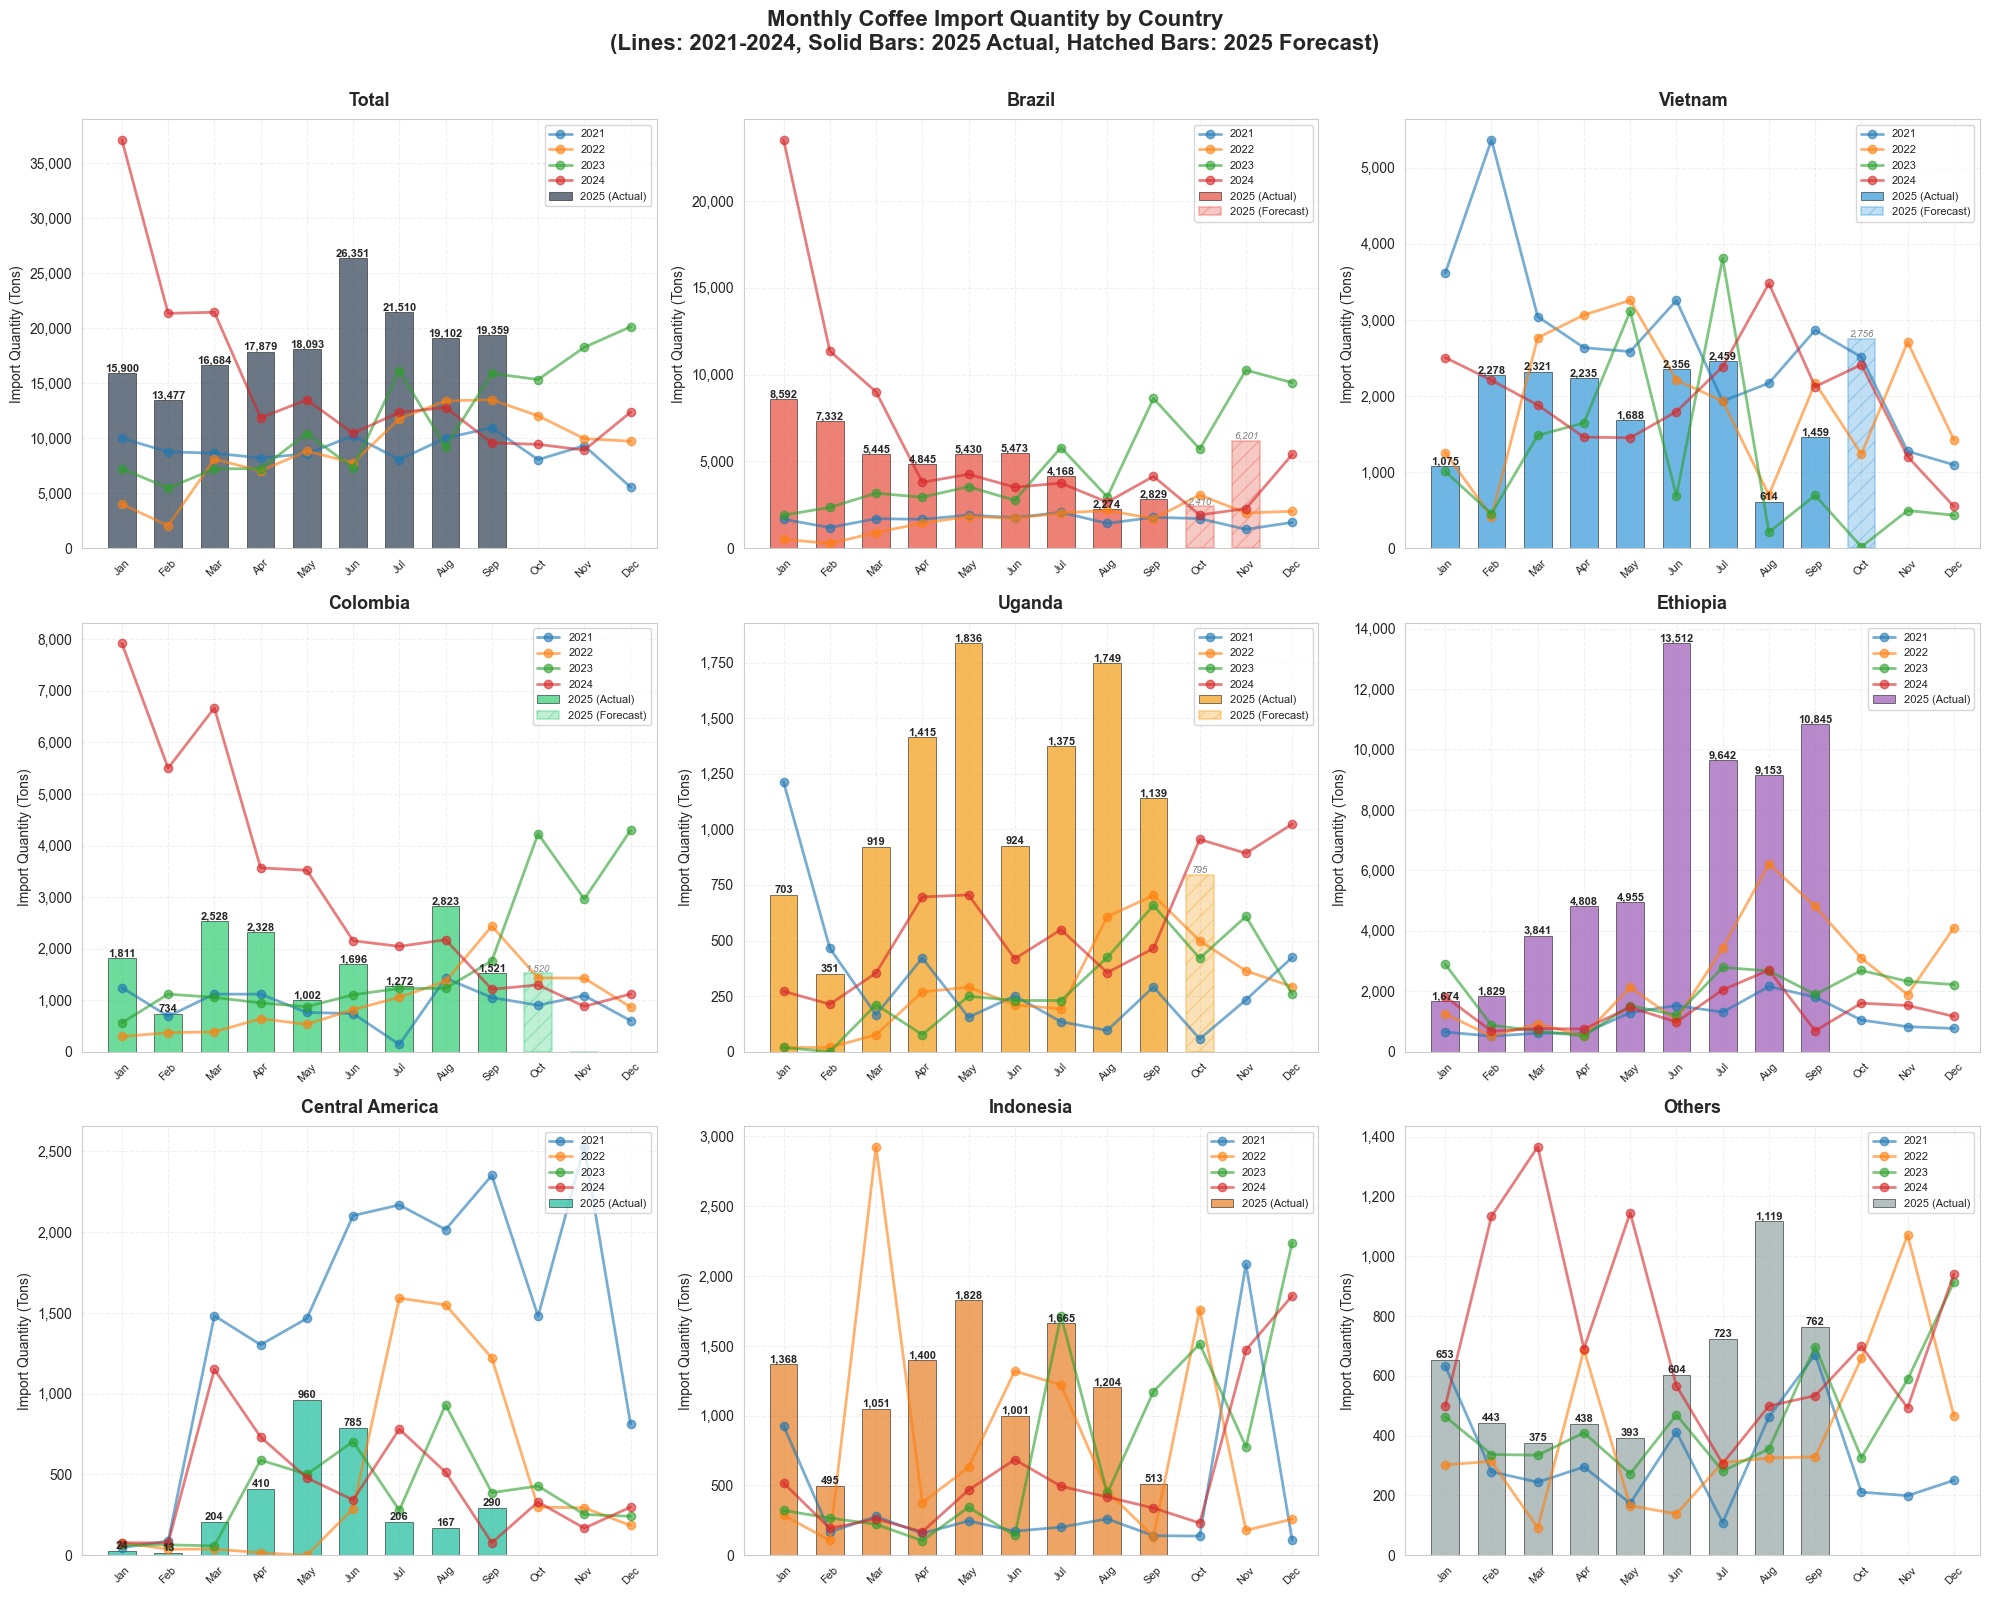

In [20]:
# 创建3x3的子图
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

# 为每个国家创建一个子图
for idx, country in enumerate(countries):
    ax = axes[idx]
    
    if country not in monthly_pivot.columns:
        ax.text(0.5, 0.5, f'No data for {country}', 
               ha='center', va='center', fontsize=12)
        ax.set_title(country, fontsize=13, fontweight='bold', pad=10)
        continue
    
    # 绘制历史年份的线图
    for year in historical_years:
        year_data = monthly_pivot[monthly_pivot['year'] == year].sort_values('month')
        if country in year_data.columns and len(year_data) > 0:
            ax.plot(year_data['month'], year_data[country], 
                   marker='o', linewidth=2, alpha=0.6,
                   label=f'{int(year)}')
    
    # 绘制最新年份的柱状图
    latest_data = monthly_pivot[monthly_pivot['year'] == latest_year].sort_values('month')
    if country in latest_data.columns and len(latest_data) > 0:
        bars = ax.bar(latest_data['month'], latest_data[country], 
                     width=0.6, label=f'{int(latest_year)} (Actual)',
                     color=color_map[country], alpha=0.7, 
                     edgecolor='black', linewidth=0.5)
        
        # 在柱子上标注数值（只标注非零值）
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:,.0f}',
                       ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # 添加预测值（如果该国家有预测数据）
    # 注意：forecast_monthly 已经被筛选，只包含没有真实数据的月份
    if country != 'Total' and country in ['Brazil', 'Vietnam', 'Colombia', 'Uganda']:
        # 获取该国家的预测数据（已筛选，只包含没有实际数据的月份）
        forecast_country_data = forecast_monthly[
            (forecast_monthly['Country_Category'] == country) & 
            (forecast_monthly['year'] == latest_year)
        ].sort_values('month')
        
        if len(forecast_country_data) > 0:
            # 使用斜杠填充的柱状图表示预测值
            bars_forecast = ax.bar(
                forecast_country_data['month'], 
                forecast_country_data['Forecast_tons'],
                width=0.6, 
                label=f'{int(latest_year)} (Forecast)',
                color=color_map[country], 
                alpha=0.3,  # 更高的透明度
                edgecolor=color_map[country], 
                linewidth=1.5,
                hatch='//'  # 斜杠填充
            )
            
            # 在预测柱子上标注数值（只标注非零值）
            for bar in bars_forecast:
                height = bar.get_height()
                if height > 0:
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:,.0f}',
                           ha='center', va='bottom', fontsize=7, 
                           fontweight='normal', style='italic', color='gray')
    
    # 设置子图属性
    ax.set_ylabel('Import Quantity (Tons)', fontsize=10)
    ax.set_title(country, fontsize=13, fontweight='bold', pad=10)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], 
                       fontsize=8, rotation=45)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # 设置y轴从0开始，并添加千分位格式
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# 添加总标题
if historical_years:
    fig.suptitle(f'Monthly Coffee Import Quantity by Country\n(Lines: {int(historical_years[0])}-{int(historical_years[-1])}, Solid Bars: {int(latest_year)} Actual, Hatched Bars: {int(latest_year)} Forecast)', 
                fontsize=16, fontweight='bold', y=0.995)
else:
    fig.suptitle(f'Monthly Coffee Import Quantity by Country ({int(latest_year)})', 
                fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.99])

# 保存图表
output_dir = Path.cwd()
output_path = output_dir / 'monthly_import_by_country.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✅ 图表已保存到：{output_path}")

plt.show()

## 📊 步骤 8: 创建第二个可视化 - 累计进口数量图

In [21]:
# 计算每年的累计进口量（实际值）
cumulative_data = []

for year in years:
    year_data = monthly_pivot[monthly_pivot['year'] == year].sort_values('month').copy()
    
    # 为每个国家计算累计值
    for country in countries:
        if country in year_data.columns:
            year_data[f'{country}_cumsum'] = year_data[country].cumsum()
    
    cumulative_data.append(year_data)

# 合并所有年份的累计数据
cumulative_pivot = pd.concat(cumulative_data, ignore_index=True)

print("✅ 累计数据计算完成！")
print(f"\n累计数据示例:")
print(cumulative_pivot[['year', 'month', 'Total_cumsum']].head(10))

# 计算预测值的累计数据（只包含没有实际数据的月份）
print("\n=== 计算预测累计数据（只包含没有实际数据的月份）===")
cumulative_forecast_data = []

for year in years:
    for country in ['Brazil', 'Vietnam', 'Colombia', 'Uganda']:
        # 获取该国家该年的预测数据（已经被筛选过，只包含没有实际数据的月份）
        country_forecast = forecast_monthly[
            (forecast_monthly['Country_Category'] == country) & 
            (forecast_monthly['year'] == year)
        ].sort_values('month').copy()
        
        if len(country_forecast) > 0:
            # 获取该国家该年的实际数据，用于计算预测的起始累计值
            country_actual = monthly_pivot[
                (monthly_pivot['year'] == year)
            ].sort_values('month').copy()
            
            # 找到该国家最后一个有实际数据的月份的累计值
            if country in country_actual.columns:
                actual_cumsum_col = f'{country}_cumsum'
                if actual_cumsum_col in cumulative_pivot.columns:
                    last_actual_cumsum = cumulative_pivot[
                        (cumulative_pivot['year'] == year) &
                        (cumulative_pivot['month'] < country_forecast['month'].min())
                    ]
                    
                    if len(last_actual_cumsum) > 0:
                        # 从最后的实际累计值开始计算预测累计值
                        base_cumsum = last_actual_cumsum[actual_cumsum_col].max()
                    else:
                        base_cumsum = 0
                else:
                    base_cumsum = 0
            else:
                base_cumsum = 0
            
            # 计算预测的累计值（基于最后的实际累计值）
            country_forecast[f'{country}_forecast_cumsum'] = base_cumsum + country_forecast['Forecast_tons'].cumsum()
            cumulative_forecast_data.append(country_forecast)

# 合并预测累计数据
if cumulative_forecast_data:
    cumulative_forecast_pivot = pd.concat(cumulative_forecast_data, ignore_index=True)
    print(f"✅ 预测累计数据计算完成！")
    print(f"   预测累计数据记录数: {len(cumulative_forecast_pivot)}")
    print(f"\n预测累计数据示例（只包含没有实际数据的月份）:")
    print(cumulative_forecast_pivot.head(10))
else:
    cumulative_forecast_pivot = pd.DataFrame()
    print("⚠️  没有预测累计数据")

✅ 累计数据计算完成！

累计数据示例:
Country_Category  year  month  Total_cumsum
0                 2021      1     10009.142
1                 2021      2     18774.716
2                 2021      3     27426.604
3                 2021      4     35639.342
4                 2021      5     44232.371
5                 2021      6     54463.085
6                 2021      7     62534.272
7                 2021      8     72561.028
8                 2021      9     83521.839
9                 2021     10     91582.806

=== 计算预测累计数据（只包含没有实际数据的月份）===
✅ 预测累计数据计算完成！
   预测累计数据记录数: 6

预测累计数据示例（只包含没有实际数据的月份）:
   year  month Country_Category  Forecast_tons  Brazil_forecast_cumsum  \
0  2025     10           Brazil        2410.44               48799.438   
1  2025     11           Brazil        6201.48               55000.918   
2  2025     10          Vietnam        2756.00                     NaN   
3  2025     10         Colombia        1519.77                     NaN   
4  2025     11         Colombia        

✅ 图表已保存到：/Users/caddyzhang/Documents/X_Codes/Caddy's data/dashboards/coffee_import_export/cumulative_import_by_country.png


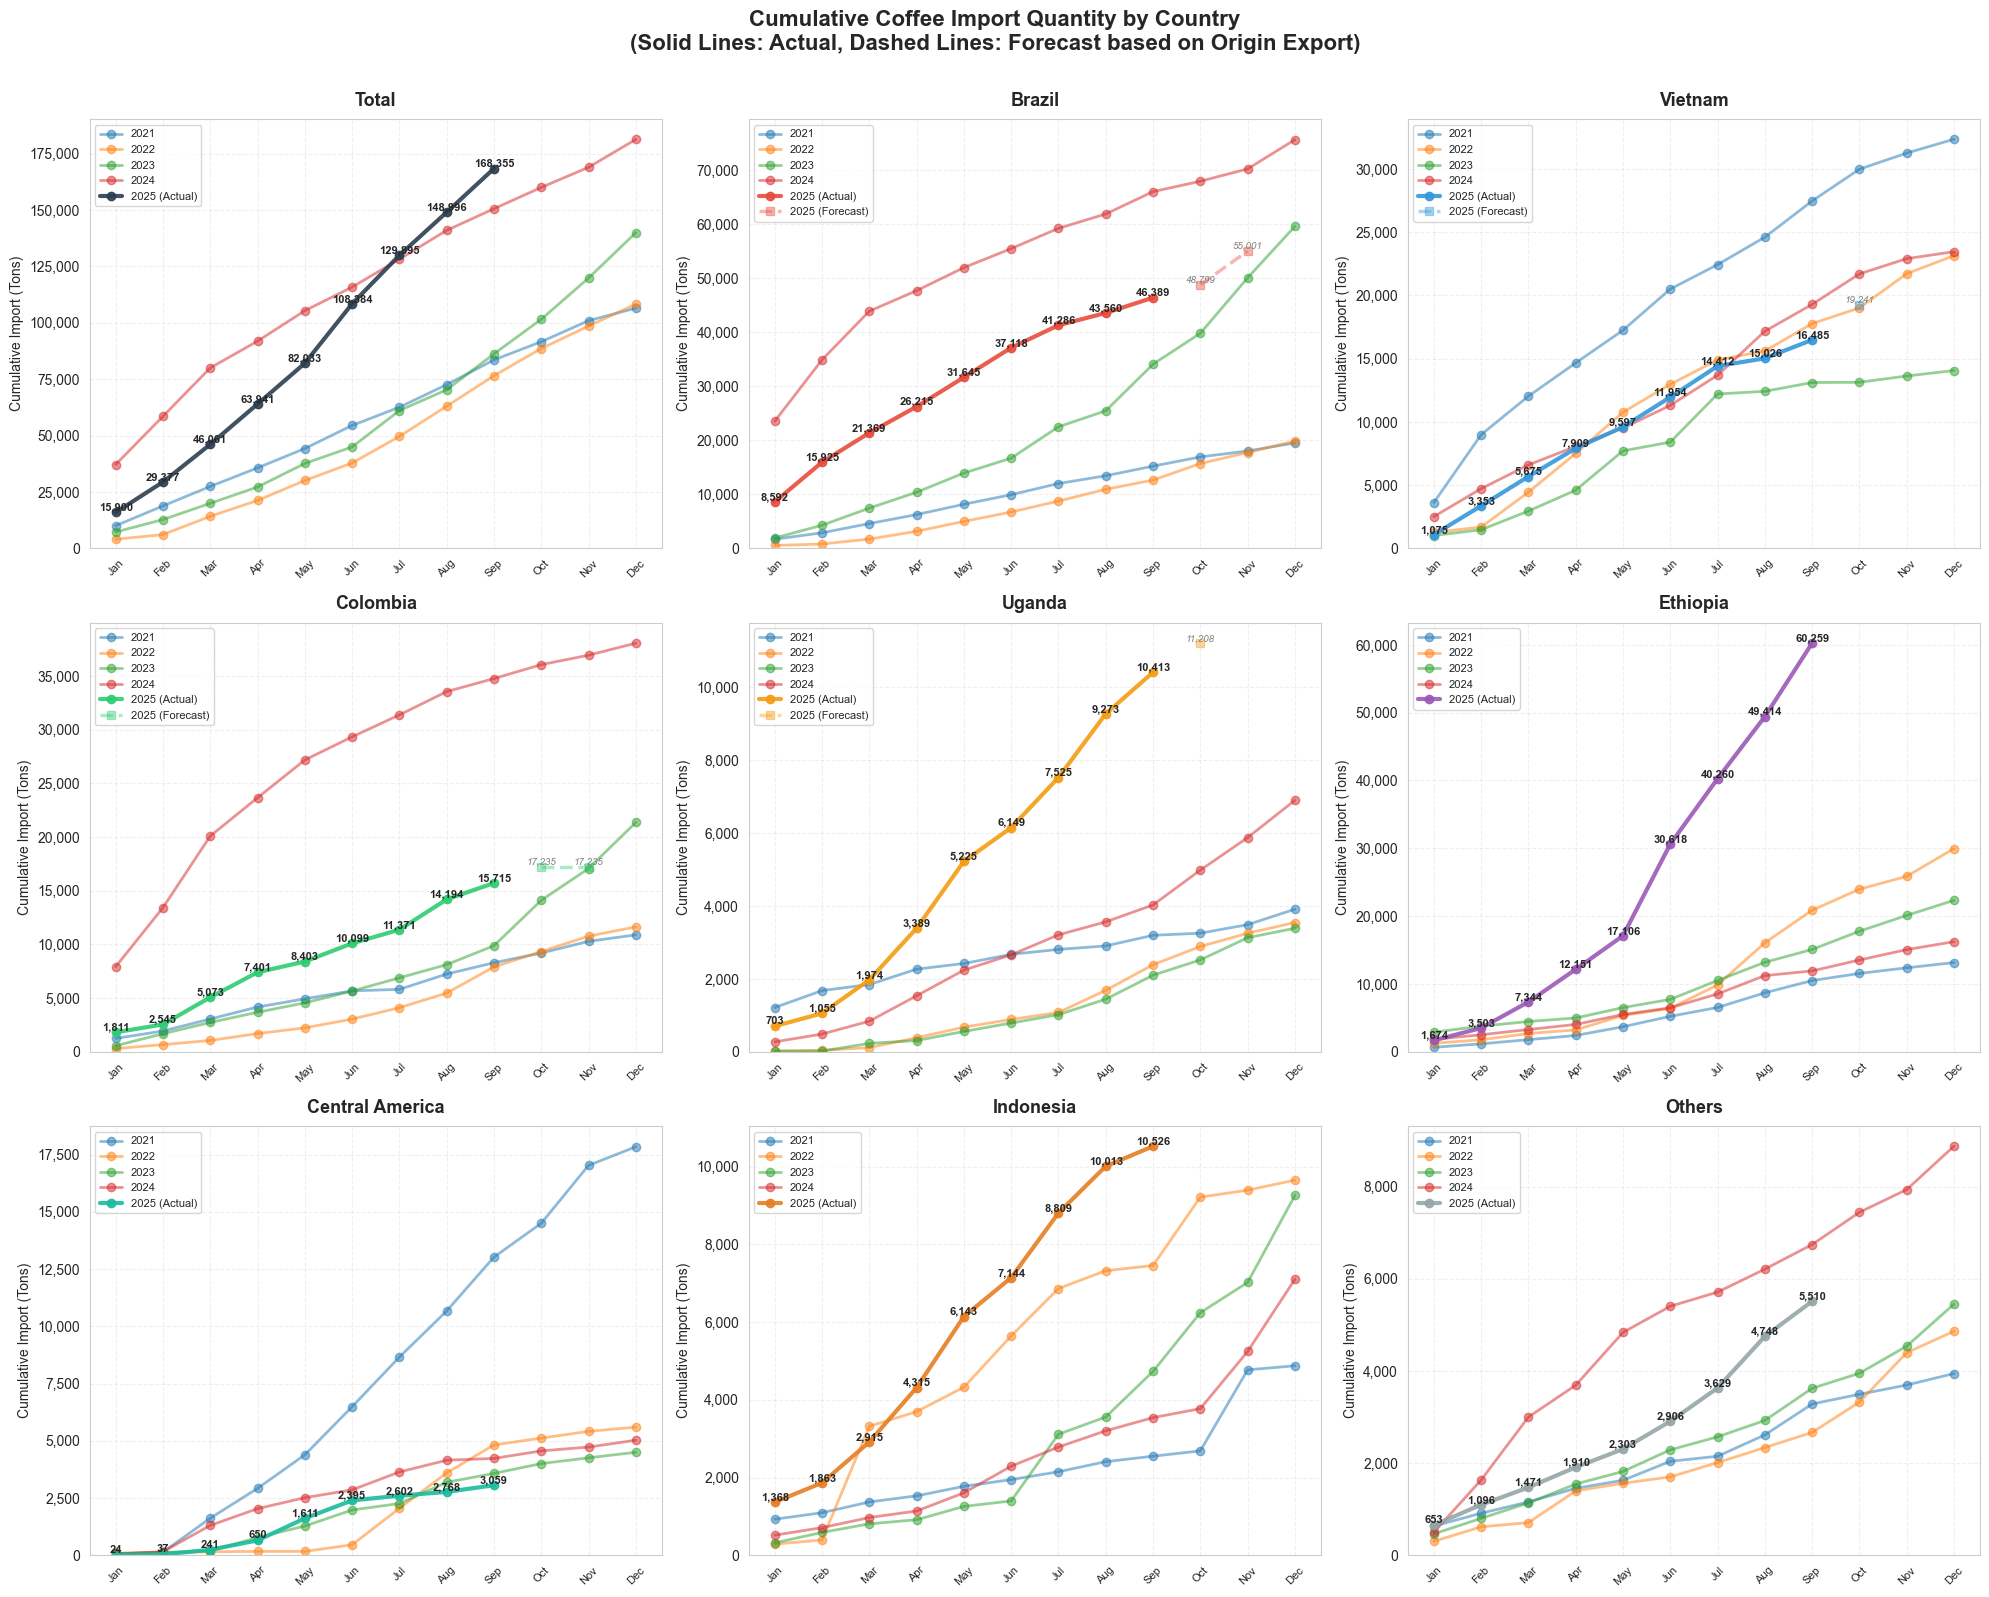

In [22]:
# 创建累计进口数量九宫格图表
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

# 为每个国家创建一个累计子图
for idx, country in enumerate(countries):
    ax = axes[idx]
    
    cumsum_col = f'{country}_cumsum'
    
    # 检查累计列是否存在
    if cumsum_col not in cumulative_pivot.columns:
        ax.text(0.5, 0.5, f'No data for {country}', 
               ha='center', va='center', fontsize=12)
        ax.set_title(country, fontsize=13, fontweight='bold', pad=10)
        continue
    
    # 绘制所有年份的累计线图（实际值）
    for year in years:
        year_data = cumulative_pivot[cumulative_pivot['year'] == year].sort_values('month')
        
        if cumsum_col in year_data.columns and len(year_data) > 0:
            if year == latest_year:
                # 最新年份用粗线和标记
                ax.plot(year_data['month'], year_data[cumsum_col], 
                       marker='o', linewidth=3, alpha=0.9,
                       color=color_map[country], label=f'{int(year)} (Actual)')
                
                # 在最新年份的点上标注数值（只标注非零值）
                for _, row in year_data.iterrows():
                    if row[cumsum_col] > 0:
                        ax.text(row['month'], row[cumsum_col],
                               f"{row[cumsum_col]:,.0f}",
                               ha='center', va='bottom', fontsize=8, fontweight='bold')
            else:
                # 历史年份用细线
                ax.plot(year_data['month'], year_data[cumsum_col], 
                       marker='o', linewidth=2, alpha=0.5,
                       label=f'{int(year)}')
    
    # 添加预测值的累计线（如果该国家有预测数据）
    if country != 'Total' and country in ['Brazil', 'Vietnam', 'Colombia', 'Uganda']:
        if len(cumulative_forecast_pivot) > 0:
            # 获取该国家最新年份的预测累计数据
            forecast_cumsum_col = f'{country}_forecast_cumsum'
            country_forecast = cumulative_forecast_pivot[
                (cumulative_forecast_pivot['Country_Category'] == country) & 
                (cumulative_forecast_pivot['year'] == latest_year)
            ].sort_values('month')
            
            if len(country_forecast) > 0 and forecast_cumsum_col in country_forecast.columns:
                # 使用虚线和更高透明度表示预测累计值
                ax.plot(
                    country_forecast['month'], 
                    country_forecast[forecast_cumsum_col],
                    marker='s',  # 方形标记
                    linewidth=2.5, 
                    alpha=0.4,  # 更高透明度
                    color=color_map[country],
                    linestyle='--',  # 虚线
                    label=f'{int(latest_year)} (Forecast)'
                )
                
                # 在预测线的点上标注数值（只标注非零值，用斜体）
                for _, row in country_forecast.iterrows():
                    if row[forecast_cumsum_col] > 0:
                        ax.text(row['month'], row[forecast_cumsum_col],
                               f"{row[forecast_cumsum_col]:,.0f}",
                               ha='center', va='bottom', fontsize=7, 
                               style='italic', color='gray')
    
    # 设置子图属性
    ax.set_ylabel('Cumulative Import (Tons)', fontsize=10)
    ax.set_title(country, fontsize=13, fontweight='bold', pad=10)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], 
                       fontsize=8, rotation=45)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # 设置y轴从0开始，并添加千分位格式
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# 添加总标题
if historical_years:
    fig.suptitle(f'Cumulative Coffee Import Quantity by Country\n(Solid Lines: Actual, Dashed Lines: Forecast based on Origin Export)', 
                fontsize=16, fontweight='bold', y=0.995)
else:
    fig.suptitle(f'Cumulative Coffee Import Quantity by Country ({int(latest_year)})', 
                fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.99])

# 保存图表
output_path = output_dir / 'cumulative_import_by_country.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✅ 图表已保存到：{output_path}")

plt.show()

## 📊 步骤 9: 创建第三个可视化 - 主要进口来源国对比

✅ 图表已保存到：/Users/caddyzhang/Documents/X_Codes/Caddy's data/dashboards/coffee_import_export/total_import_by_country.png


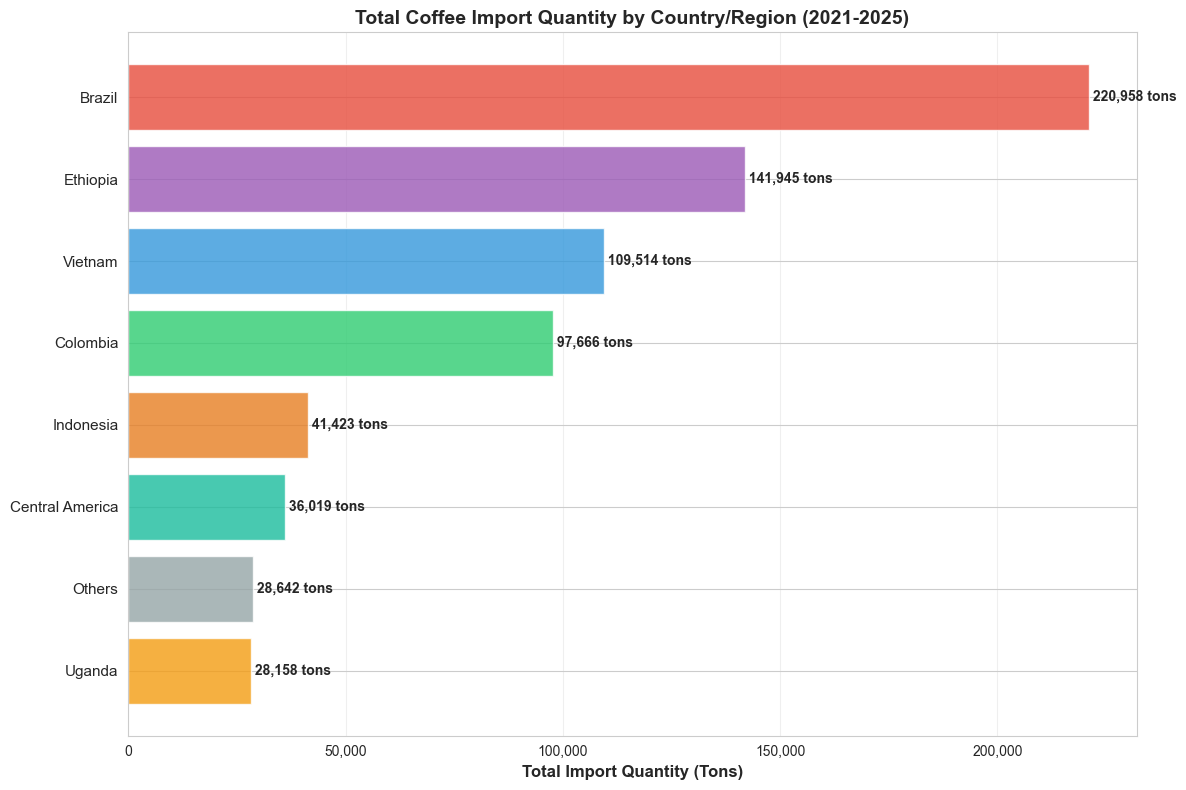

In [23]:
# 计算每个国家的总进口量
total_by_country = import_data.groupby('Country_Category')['Quantity_tons'].sum().sort_values(ascending=False)

# 创建水平柱状图
fig, ax = plt.subplots(figsize=(12, 8))

# 绘制柱状图
colors_list = [color_map.get(country, '#95a5a6') for country in total_by_country.index]
bars = ax.barh(range(len(total_by_country)), total_by_country.values, color=colors_list, alpha=0.8)

# 在柱子上标注数值
for i, (bar, value) in enumerate(zip(bars, total_by_country.values)):
    ax.text(value, i, f' {value:,.0f} tons', 
           va='center', ha='left', fontsize=10, fontweight='bold')

ax.set_yticks(range(len(total_by_country)))
ax.set_yticklabels(total_by_country.index, fontsize=11)
ax.set_xlabel('Total Import Quantity (Tons)', fontsize=12, fontweight='bold')
ax.set_title(f'Total Coffee Import Quantity by Country/Region ({int(import_data["year"].min())}-{int(import_data["year"].max())})', 
            fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()

# 保存图表
output_path = output_dir / 'total_import_by_country.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✅ 图表已保存到：{output_path}")

plt.show()

## 📝 步骤 10: 导出数据到 CSV

In [24]:
# 导出月度数据
monthly_export = monthly_pivot.copy()
monthly_export['year_month'] = monthly_export['year'].astype(int).astype(str) + '-' + monthly_export['month'].astype(int).astype(str).str.zfill(2)
monthly_export = monthly_export[['year_month', 'year', 'month'] + countries]

output_path = output_dir / 'monthly_import_data.csv'
monthly_export.to_csv(output_path, index=False)
print(f"✅ 月度数据已导出到：{output_path}")

# 导出累计数据
cumulative_export = cumulative_pivot.copy()
cumulative_export['year_month'] = cumulative_export['year'].astype(int).astype(str) + '-' + cumulative_export['month'].astype(int).astype(str).str.zfill(2)
cumsum_cols = [f'{c}_cumsum' for c in countries if f'{c}_cumsum' in cumulative_export.columns]
cumulative_export = cumulative_export[['year_month', 'year', 'month'] + cumsum_cols]

output_path = output_dir / 'cumulative_import_data.csv'
cumulative_export.to_csv(output_path, index=False)
print(f"✅ 累计数据已导出到：{output_path}")

# 导出国家总计数据
output_path = output_dir / 'total_by_country.csv'
total_by_country.to_csv(output_path, header=['Total_Quantity_Tons'])
print(f"✅ 国家总计已导出到：{output_path}")

✅ 月度数据已导出到：/Users/caddyzhang/Documents/X_Codes/Caddy's data/dashboards/coffee_import_export/monthly_import_data.csv
✅ 累计数据已导出到：/Users/caddyzhang/Documents/X_Codes/Caddy's data/dashboards/coffee_import_export/cumulative_import_data.csv
✅ 国家总计已导出到：/Users/caddyzhang/Documents/X_Codes/Caddy's data/dashboards/coffee_import_export/total_by_country.csv


## ✅ 完成！

### 🎉 已生成的可视化图表：

1. **monthly_import_by_country.png** - 单月进口数量九宫格图
   - 9个子图展示 Total 和各主要国家/地区
   - 历史年份用线图，最新年份用柱状图
   - **实际值**：深色实心柱状图
   - **预测值**：浅色斜杠填充柱状图（基于原产国出口数据）
   - 包含具体数值标注

2. **cumulative_import_by_country.png** - 累计进口数量九宫格图
   - 显示各年度的累计进口趋势
   - **实际值**：实线（最新年份为粗线）
   - **预测值**：虚线（基于原产国出口数据）
   - 最新年份重点标注

3. **total_import_by_country.png** - 国家/地区总进口量对比
   - 横向柱状图对比各国总进口量
   - 按数量降序排列

---

### 🔮 预测逻辑说明

图表中包含基于原产国出口数据的预测值：

**预测延迟时间**（考虑运输时间）：
- 🇧🇷 **Brazil**: 2个月延迟（9月出口 → 11月中国进口）
- 🇨🇴 **Colombia**: 2个月延迟（9月出口 → 11月中国进口）
- 🇻🇳 **Vietnam**: 1个月延迟（9月出口 → 10月中国进口）
- 🇺🇬 **Uganda**: 1个月延迟（9月出口 → 10月中国进口）

**图表标识**：
- **单月图**: 斜杠填充（//）+ 高透明度 = 预测值
- **累计图**: 虚线（--）+ 方形标记 = 预测累计值

---

### 📊 已导出的数据文件：

1. **monthly_import_data.csv** - 月度进口数据
2. **cumulative_import_data.csv** - 累计进口数据
3. **total_by_country.csv** - 各国总进口量

---

### 🚀 下一步你可以：

1. **分享图表**：直接将 PNG 图片分享给他人
2. **调整可视化**：修改颜色、字体、大小等参数
3. **添加更多分析**：基于现有数据创建更多图表
4. **创建交互式仪表板**：使用 Streamlit 创建 Web 应用
5. **分析预测准确度**：对比实际值与预测值的差异

所有图表和数据都保存在当前目录！